Purpose: Create a depth-across-chromosome figure for uniquely mapped Nanopore reads (from minimap2).<br>
Author: Anna Pardo<br>
Date initiated: Feb. 23, 2026

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# load chrom length data
clen = pd.read_csv("./sizes_Yg.genome",sep="\t",header=None)
clen.head()

,0,1
0,Ya_Chr01,329096251
1,Ya_Chr02,307946356
2,Ya_Chr03,282269135
3,Ya_Chr04,274644142
4,Ya_Chr05,243392519


In [3]:
# load read depth/coverage data
cov = pd.read_csv("./YgG_nolf_unique.regions.bed.gz",sep="\t",header=None)
cov.head()

,0,1,2,3
0,Ya_Chr01,0,2000,8.88
1,Ya_Chr01,2000,4000,12.82
2,Ya_Chr01,4000,6000,17.25
3,Ya_Chr01,6000,8000,20.68
4,Ya_Chr01,8000,10000,22.95


In [30]:
# wrangle chromosome length data
## desired output: df with columns = chrID, Ya length, Yf length
yachr = clen.head(30)
yfchr = clen.tail(30)


In [31]:
yachr.rename(columns={0:"id",1:"len"},inplace=True)

/tmp/ipykernel_12328/2843222887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yachr.rename(columns={0:"id",1:"len"},inplace=True)


In [32]:

yachr["chrID"] = yachr["id"].str.split("_").str[1]
yachr["species"] = "Ya"
yachr.head()

/tmp/ipykernel_12328/2345953749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yachr["chrID"] = yachr["id"].str.split("_").str[1]
/tmp/ipykernel_12328/2345953749.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yachr["species"] = "Ya"


,id,len,chrID,species
0,Ya_Chr01,329096251,Chr01,Ya
1,Ya_Chr02,307946356,Chr02,Ya
2,Ya_Chr03,282269135,Chr03,Ya
3,Ya_Chr04,274644142,Chr04,Ya
4,Ya_Chr05,243392519,Chr05,Ya


In [33]:
# do the same for yfchr
yfchr.rename(columns={0:"id",1:"len"},inplace=True)
yfchr["chrID"] = yfchr["id"].str.split("_").str[1]
yfchr["species"] = "Yf"
yfchr.head()

/tmp/ipykernel_12328/162197884.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yfchr.rename(columns={0:"id",1:"len"},inplace=True)
/tmp/ipykernel_12328/162197884.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yfchr["chrID"] = yfchr["id"].str.split("_").str[1]
/tmp/ipykernel_12328/162197884.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

,id,len,chrID,species
1773,Yf_Chr01,308550522,Chr01,Yf
1774,Yf_Chr02,290700443,Chr02,Yf
1775,Yf_Chr03,293021979,Chr03,Yf
1776,Yf_Chr04,268664617,Chr04,Yf
1777,Yf_Chr05,233516983,Chr05,Yf


In [34]:
allchr = pd.concat([yachr[["chrID","len","species"]],yfchr[["chrID","len","species"]]])
allchr.head()

,chrID,len,species
0,Chr01,329096251,Ya
1,Chr02,307946356,Ya
2,Chr03,282269135,Ya
3,Chr04,274644142,Ya
4,Chr05,243392519,Ya


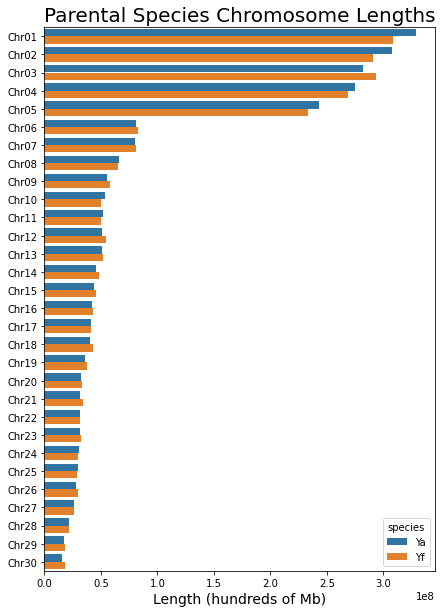

In [40]:
# plot the chromosome lengths for the homeologs, just for kicks
fig,ax = plt.subplots(figsize=(7,10))
sns.barplot(data=allchr,y="chrID",x="len",hue="species")
plt.title("Parental Species Chromosome Lengths",fontsize=20)
plt.ylabel("")
plt.xlabel("Length (hundreds of Mb)",fontsize=14)

plt.savefig("./chromlengths_YaYf.png",dpi=200,bbox_inches="tight")
plt.savefig("./chromlengths_YaYf.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./chromlengths_YaYf.svg",dpi=200,bbox_inches="tight")

In [45]:
# test: plot for chr30
## make a function to check which homeolog is longer
def check_homeo_length(cid):
    df = allchr[allchr["chrID"]==cid].sort_values(by="len",ascending=False)
    highest_len = df.iloc[0,1]
    return highest_len

In [47]:
x_axis_len = check_homeo_length("Chr30")

In [49]:
cov.rename(columns={0:"id",1:"window_start",2:"window_stop",3:"mean_depth"},inplace=True)
cov.head()

,id,window_start,window_stop,mean_depth
0,Ya_Chr01,0,2000,8.88
1,Ya_Chr01,2000,4000,12.82
2,Ya_Chr01,4000,6000,17.25
3,Ya_Chr01,6000,8000,20.68
4,Ya_Chr01,8000,10000,22.95


In [50]:
cov["chrID"] = cov["id"].str.split("_").str[1]
cov.head()

,id,window_start,window_stop,mean_depth,chrID
0,Ya_Chr01,0,2000,8.88,Chr01
1,Ya_Chr01,2000,4000,12.82,Chr01
2,Ya_Chr01,4000,6000,17.25,Chr01
3,Ya_Chr01,6000,8000,20.68,Chr01
4,Ya_Chr01,8000,10000,22.95,Chr01


In [51]:
cov["species"] = cov["id"].str.split("_").str[0]
cov.head()

,id,window_start,window_stop,mean_depth,chrID,species
0,Ya_Chr01,0,2000,8.88,Chr01,Ya
1,Ya_Chr01,2000,4000,12.82,Chr01,Ya
2,Ya_Chr01,4000,6000,17.25,Chr01,Ya
3,Ya_Chr01,6000,8000,20.68,Chr01,Ya
4,Ya_Chr01,8000,10000,22.95,Chr01,Ya


In [52]:
# function to subset the coverage data
def subdepth_chr(cid,depth=cov):
    df = depth[depth["chrID"]==cid]
    return df

In [53]:
c30 = subdepth_chr("Chr30")

In [54]:
c30.head()

,id,window_start,window_stop,mean_depth,chrID,species
1228051,Ya_Chr30,0,2000,10.33,Chr30,Ya
1228052,Ya_Chr30,2000,4000,17.35,Chr30,Ya
1228053,Ya_Chr30,4000,6000,24.71,Chr30,Ya
1228054,Ya_Chr30,6000,8000,29.03,Chr30,Ya
1228055,Ya_Chr30,8000,10000,30.00,Chr30,Ya


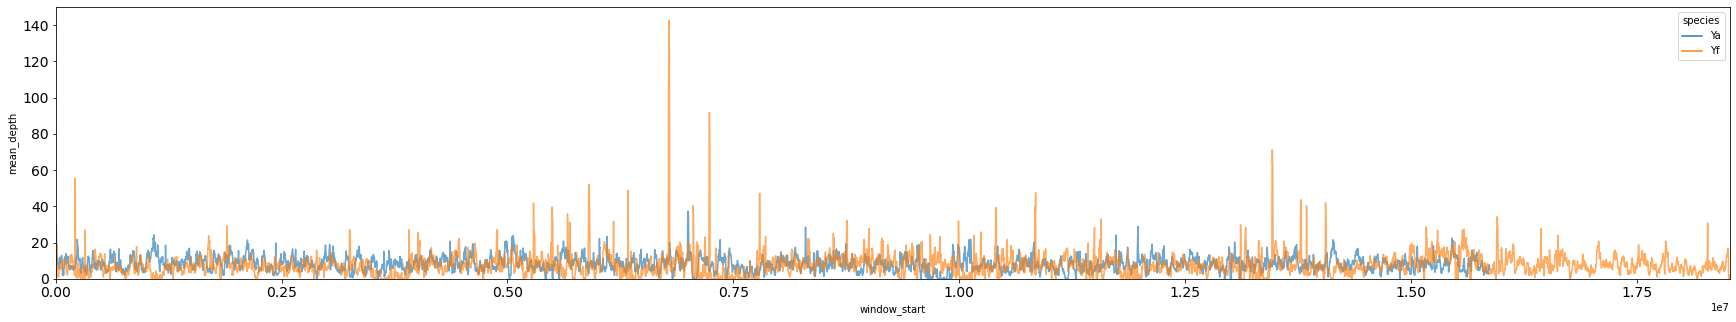

In [64]:
# try plotting
fig,ax = plt.subplots(figsize=(30,5))
sns.lineplot(data=c30,y="mean_depth",x="window_start",hue="species",alpha=0.65)
plt.xlim((0,x_axis_len))
plt.ylim((0,max(c30["mean_depth"])*1.05))
ax.tick_params(which="both",labelsize=14)

In [66]:
# set up a function to do all of this for a given chromosome
def plot_chr(cid,outdir):
    upper_xlim = check_homeo_length(cid)
    cdf = subdepth_chr(cid)
    fig,ax = plt.subplots(figsize=(30,5))
    sns.lineplot(data=cdf,y="mean_depth",x="window_start",hue="species",alpha=0.65)
    plt.xlim((0,upper_xlim))
    plt.ylim((0,max(cdf["mean_depth"])*1.05))
    plt.xlabel("Chromosome position",fontsize=16)
    plt.ylabel("Mean uniquely mapped read depth",fontsize=14)
    ax.tick_params(which="both",labelsize=14)
    plt.title(cid+" uniquely mapped Nanopore read depth for Y. gloriosa genotype G",fontsize=24)
    
    fbase = cid+"_homeolog_Nanopore_mapping"
    
    plt.savefig(os.path.join(outdir,fbase+".png"),dpi=200,bbox_inches="tight")
    plt.savefig(os.path.join(outdir,fbase+".pdf"),dpi=200,bbox_inches="tight")
    plt.savefig(os.path.join(outdir,fbase+".svg"),dpi=200,bbox_inches="tight")

In [67]:
d = "./chrom_depth_plots"

/tmp/ipykernel_12328/2854756515.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(figsize=(30,5))


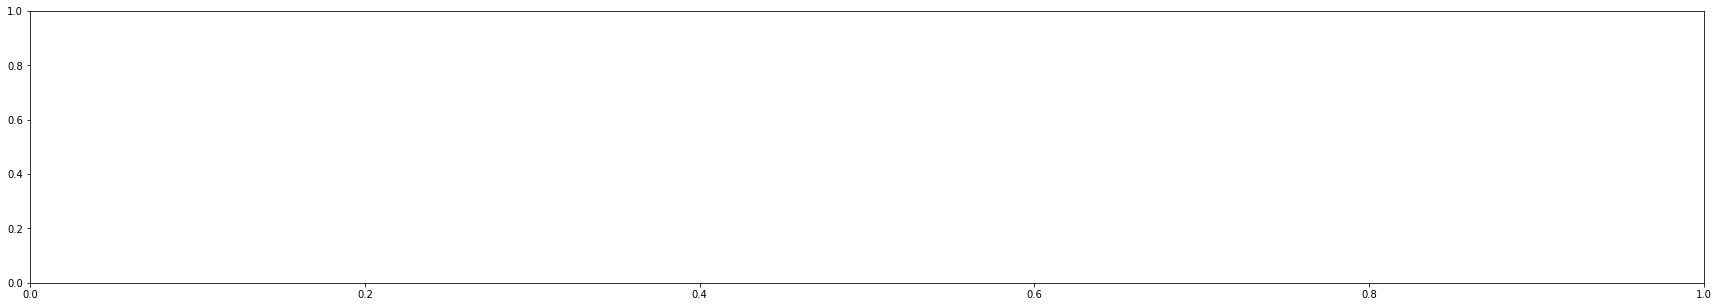

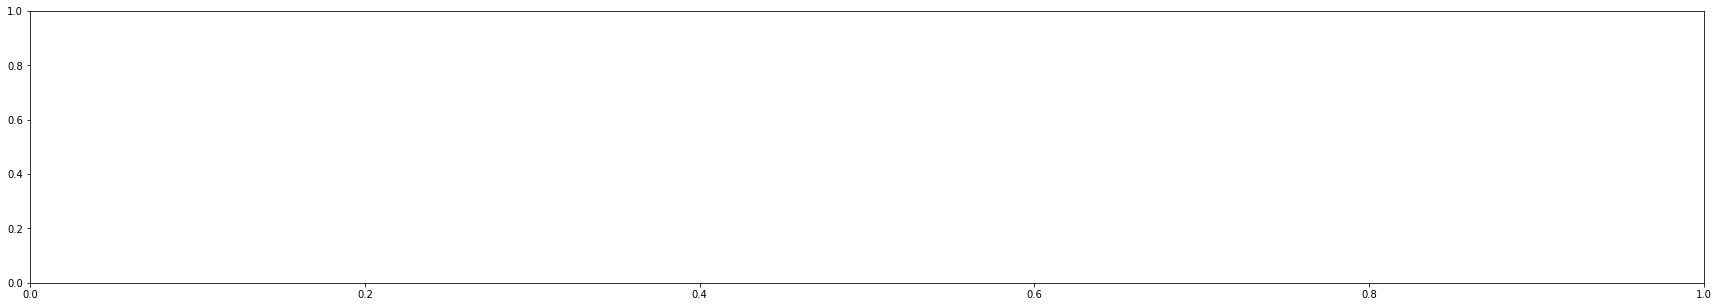

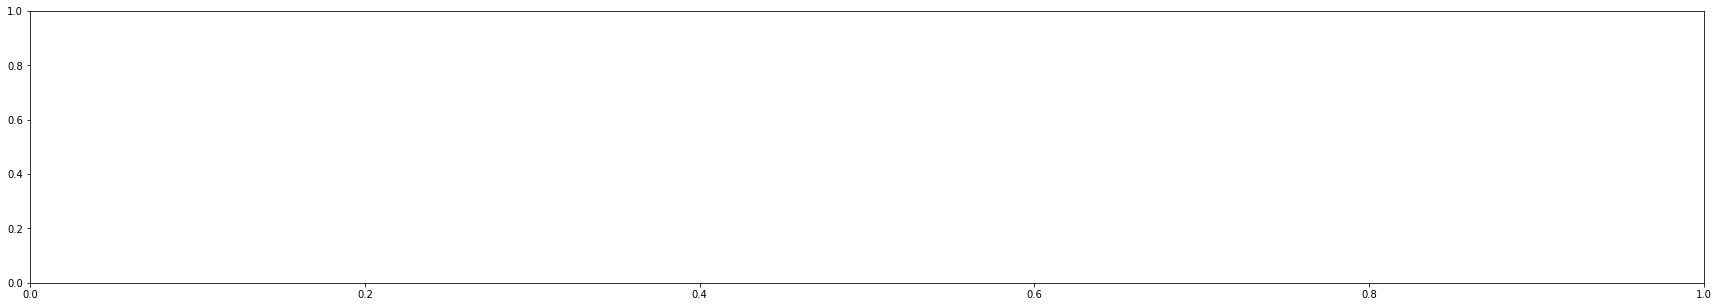

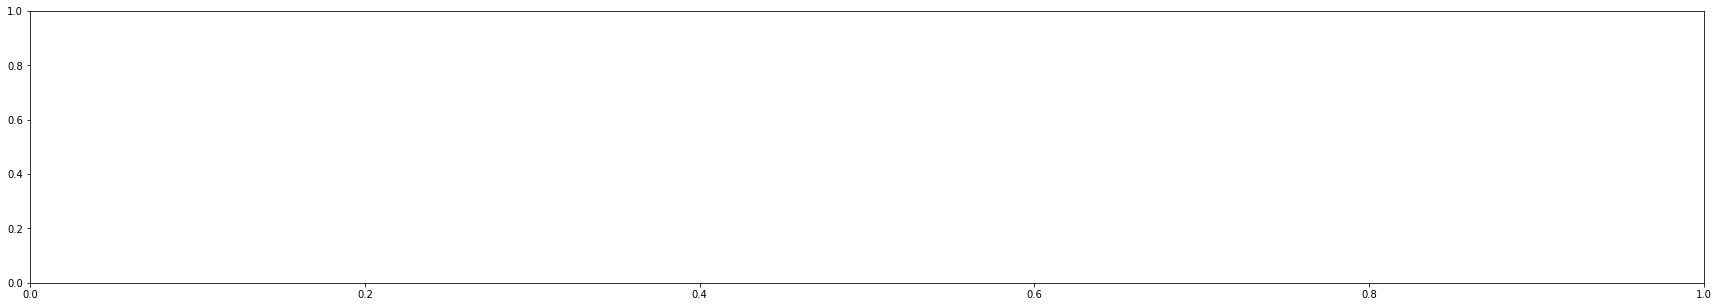

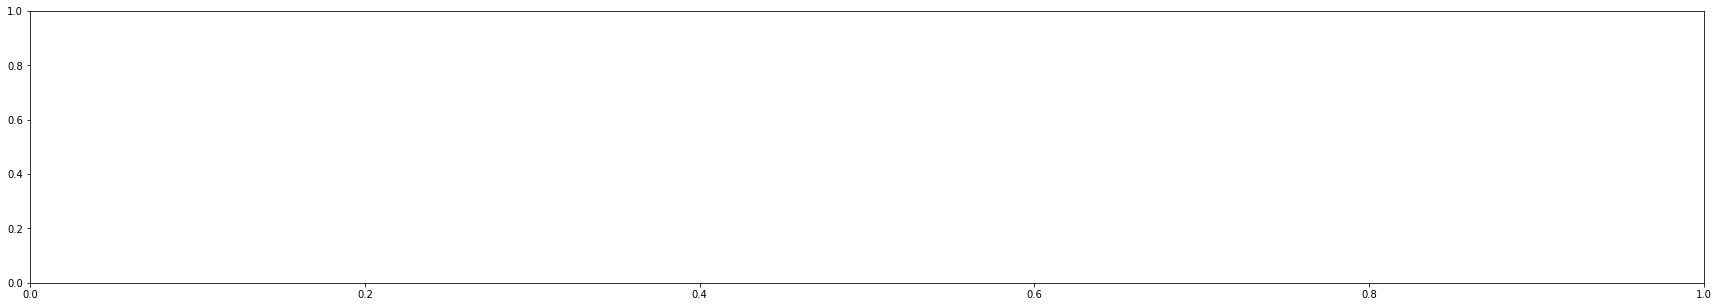

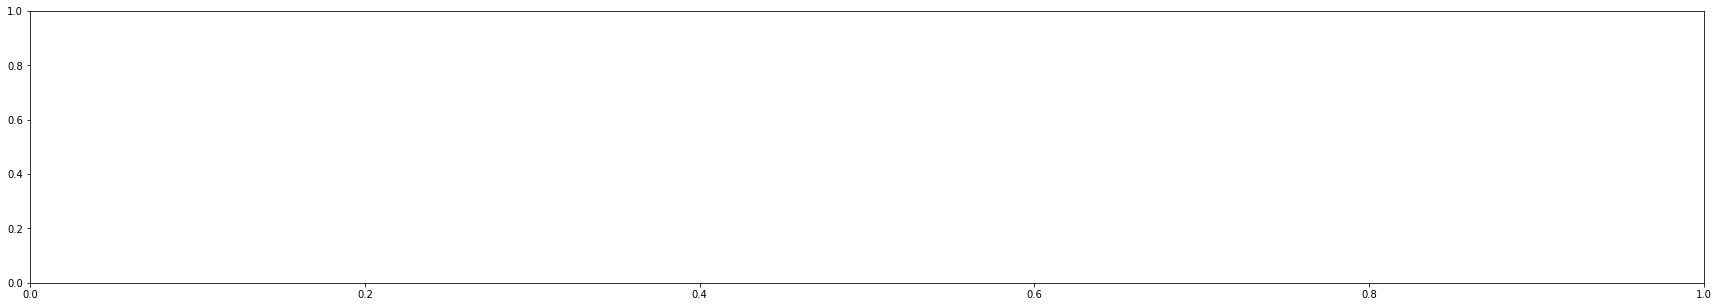

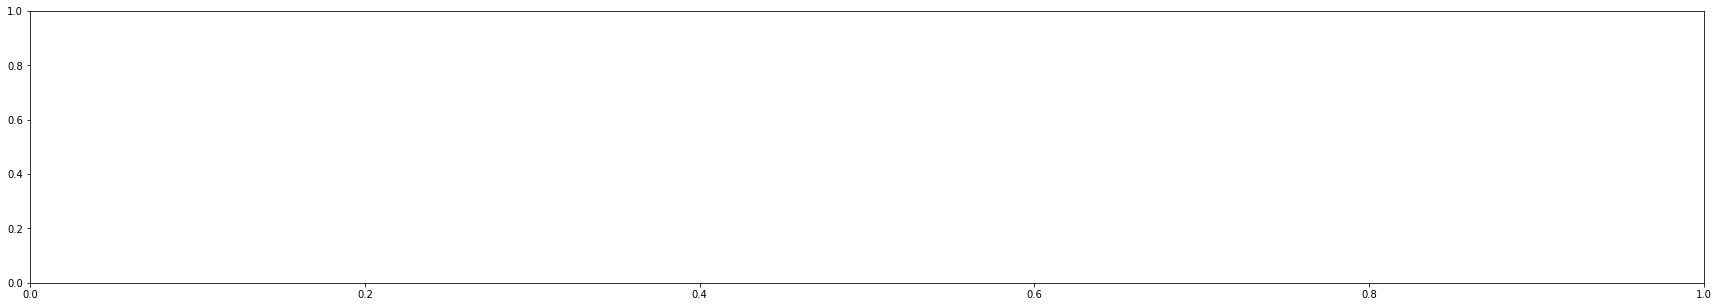

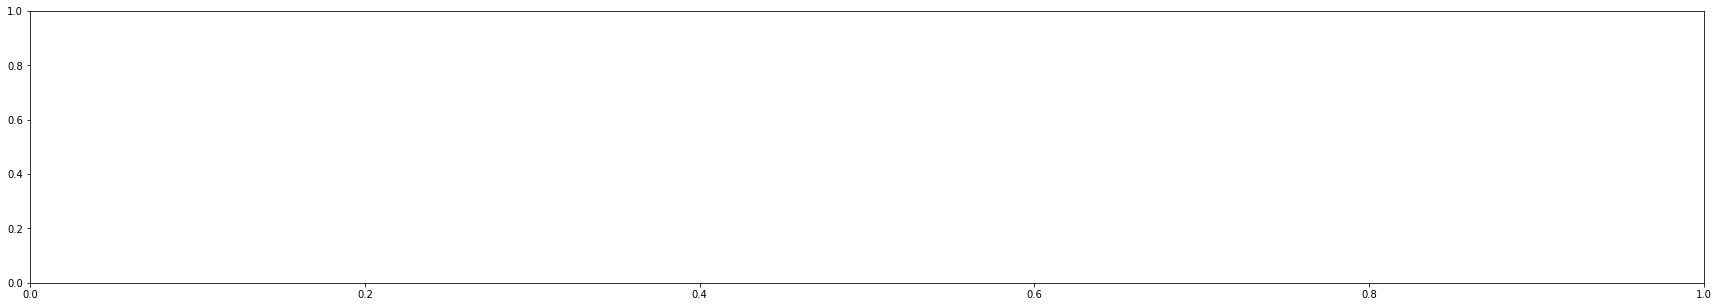

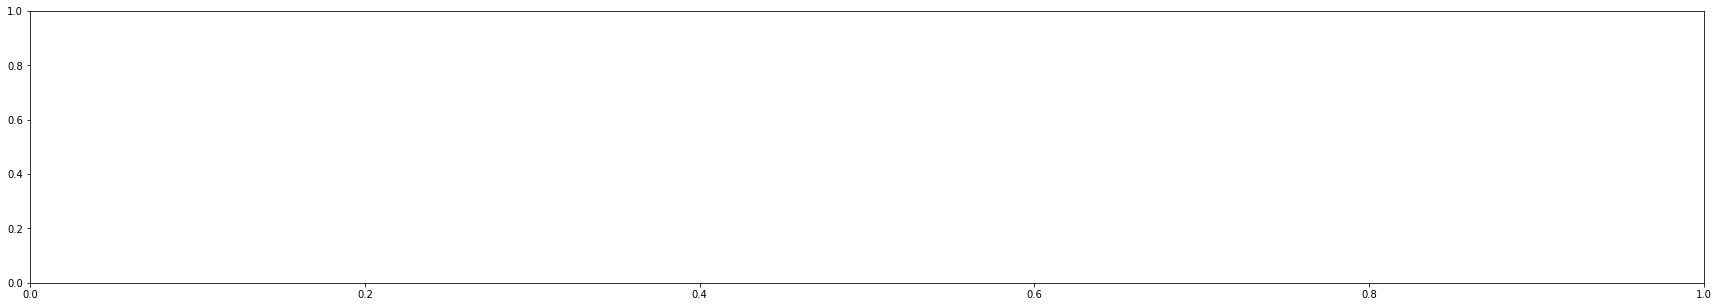

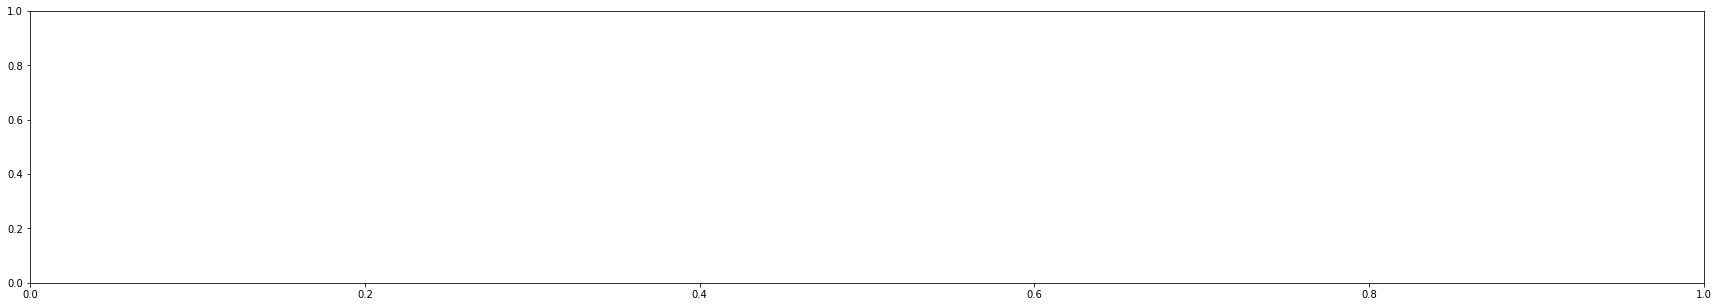

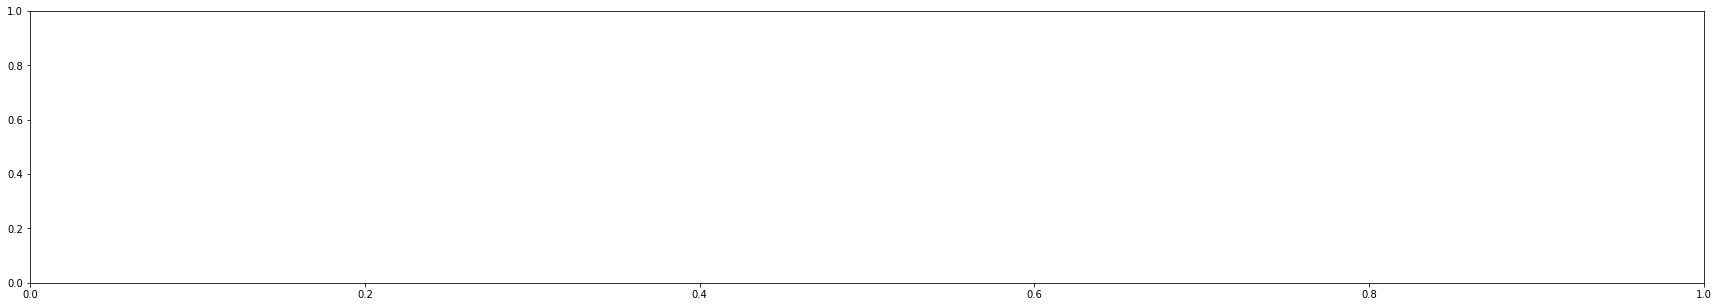

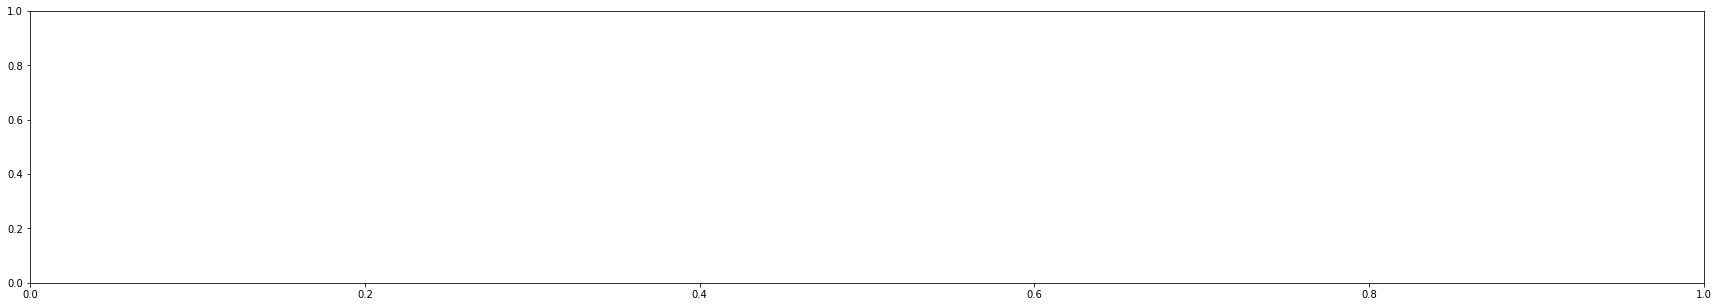

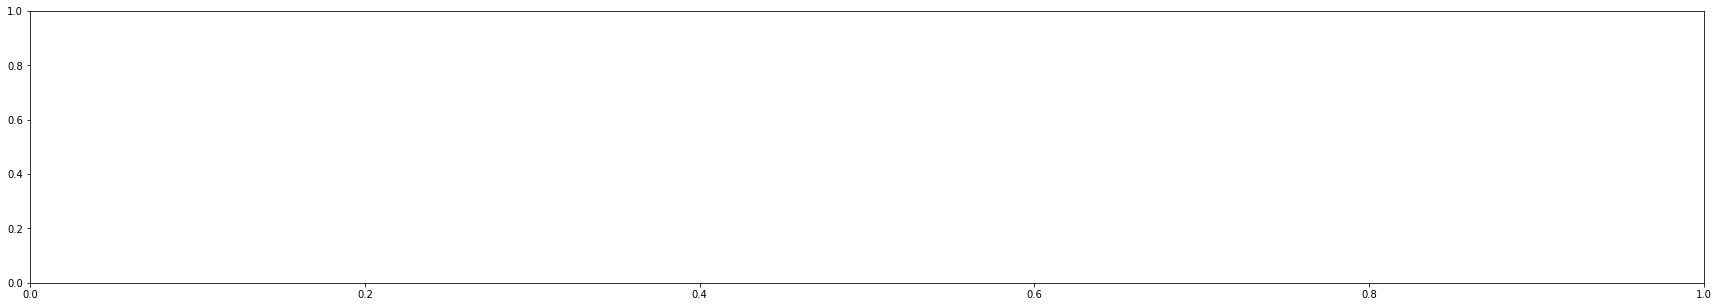

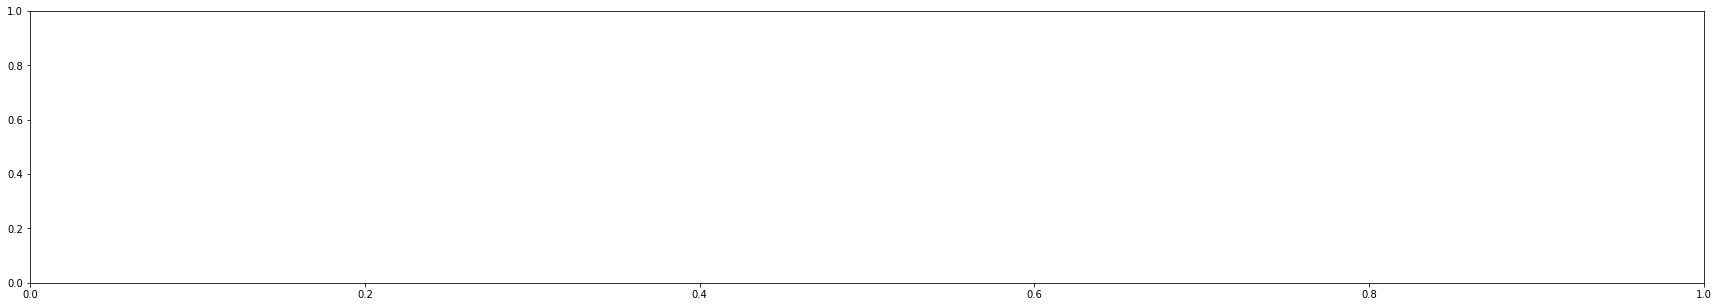

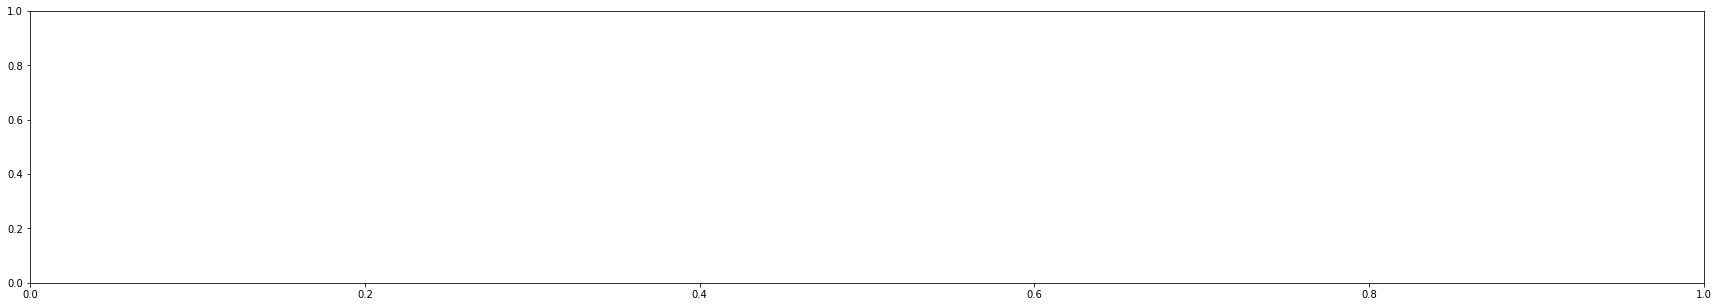

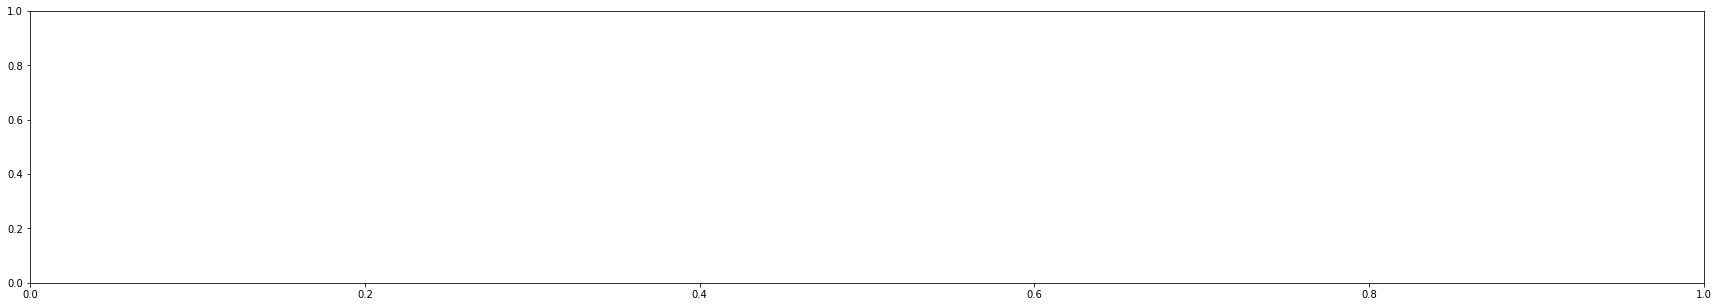

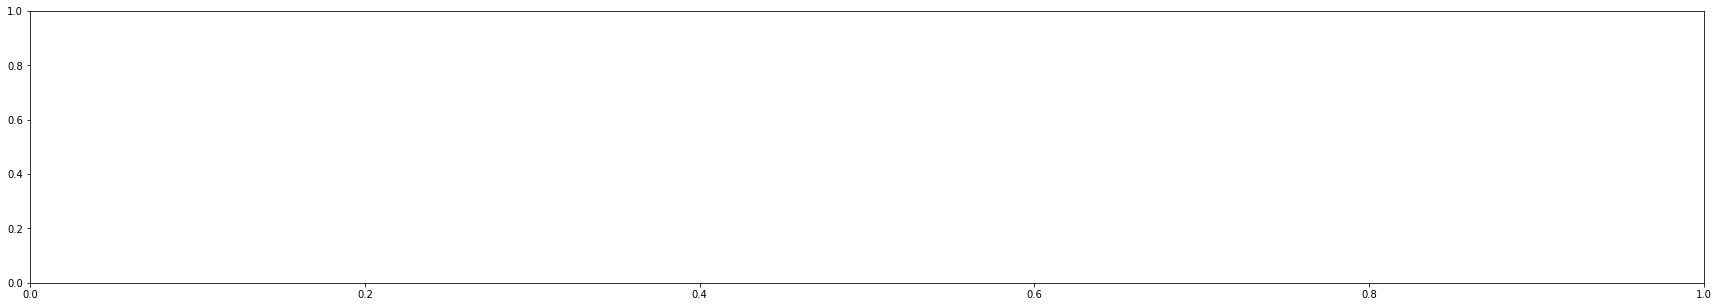

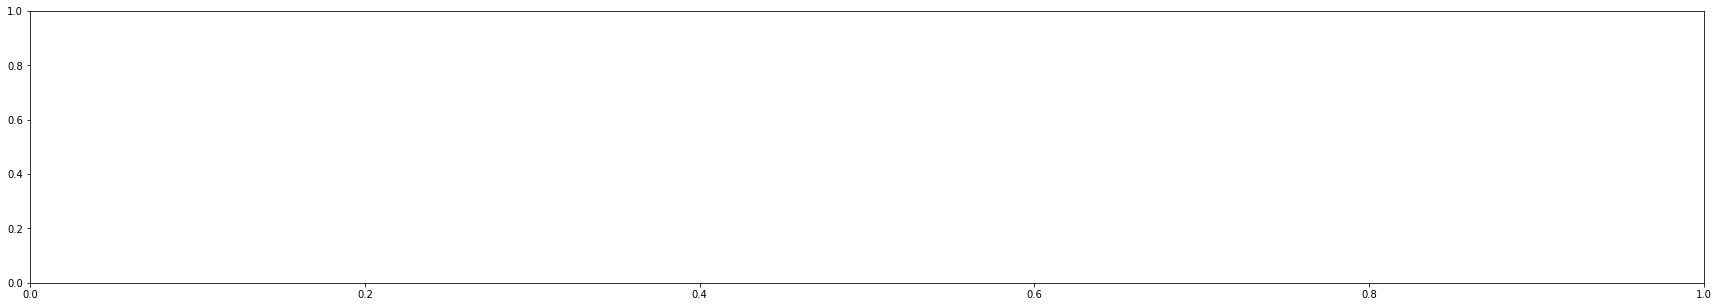

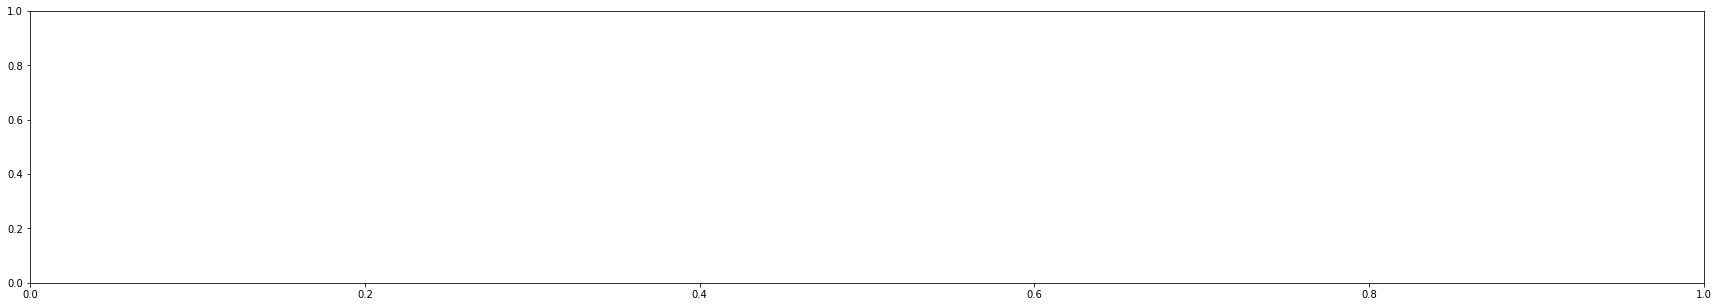

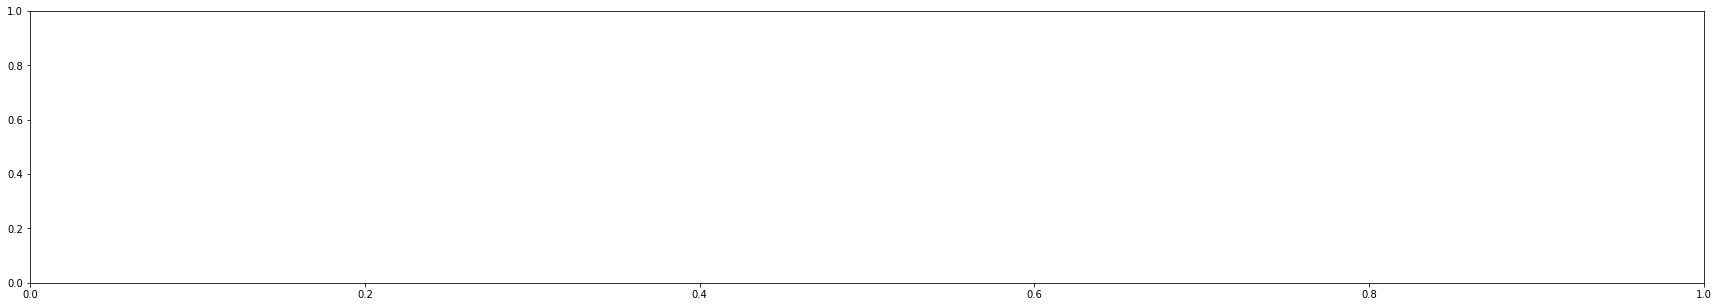

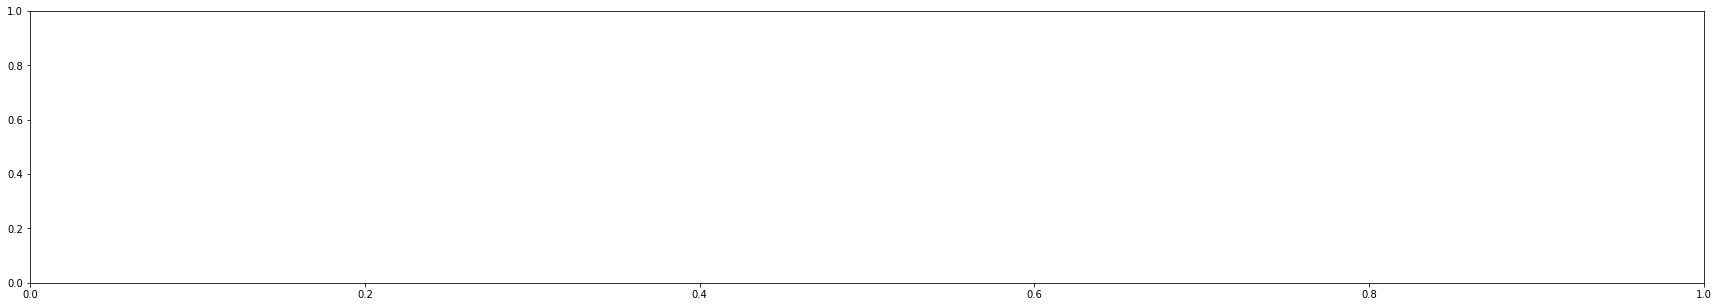

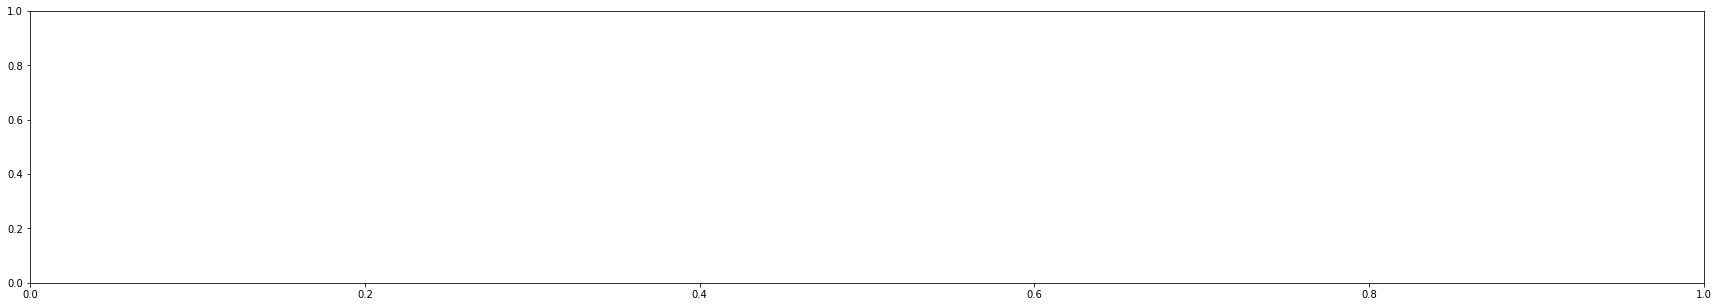

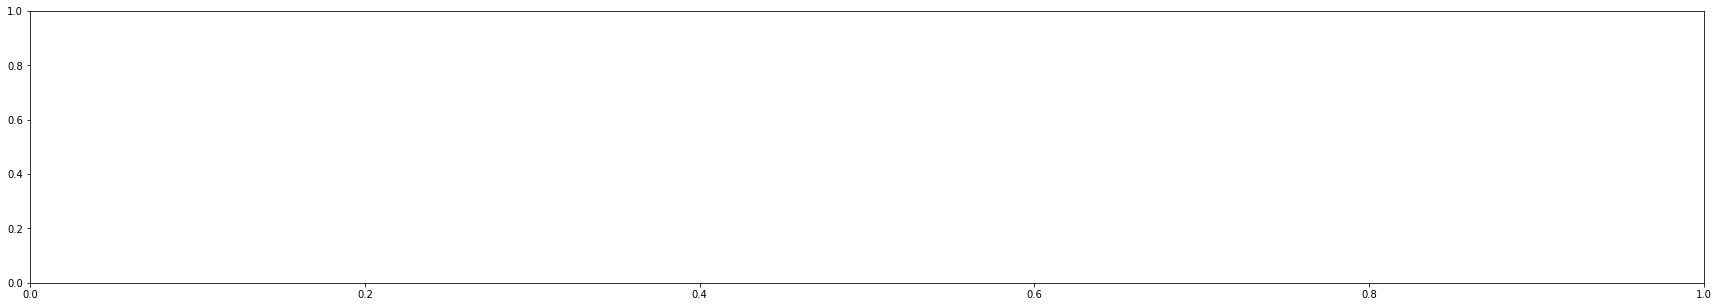

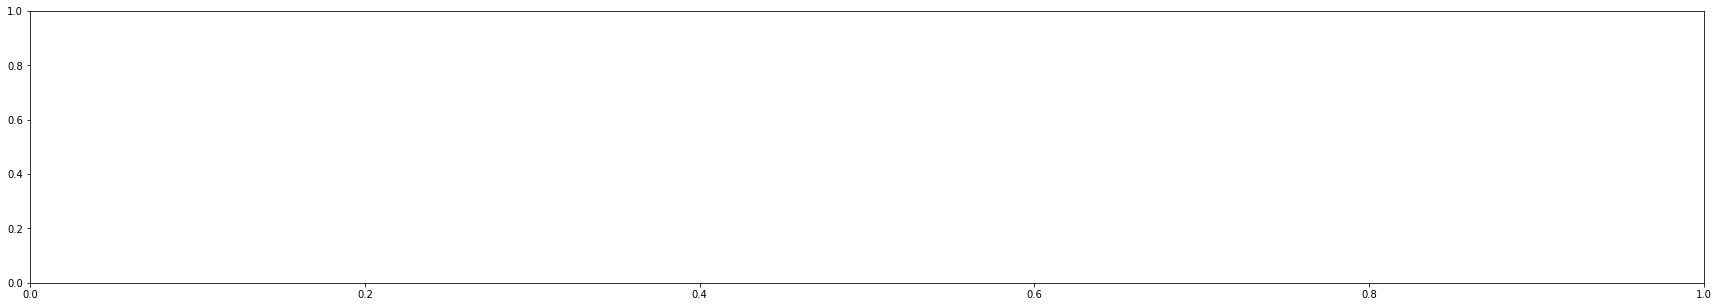

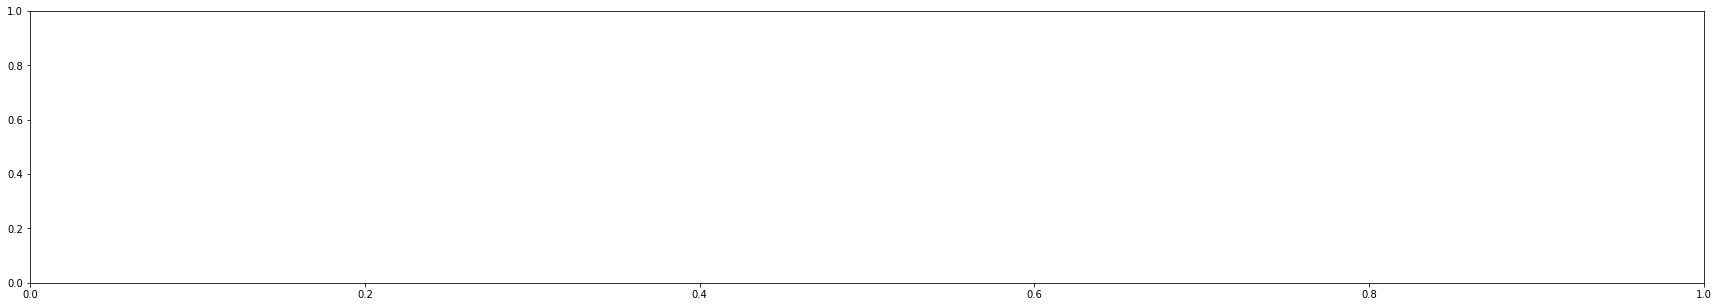

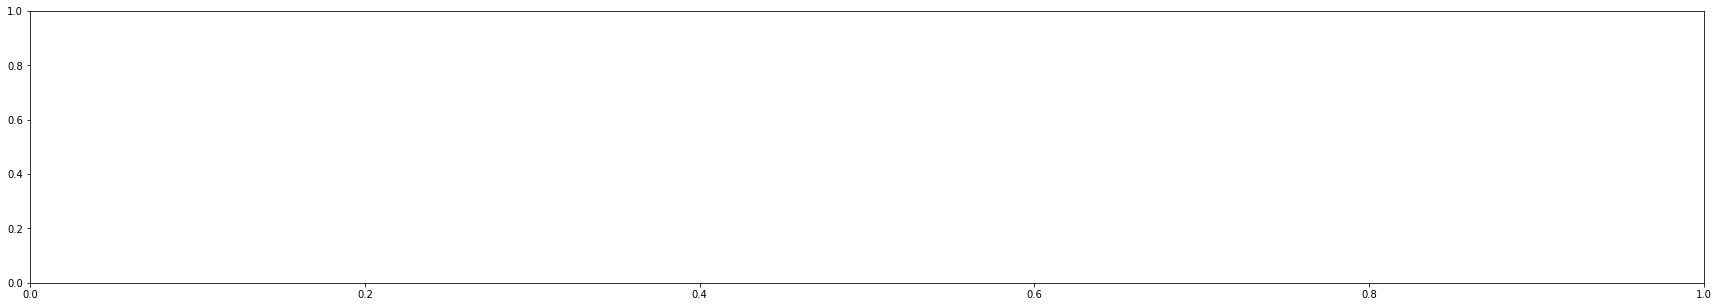

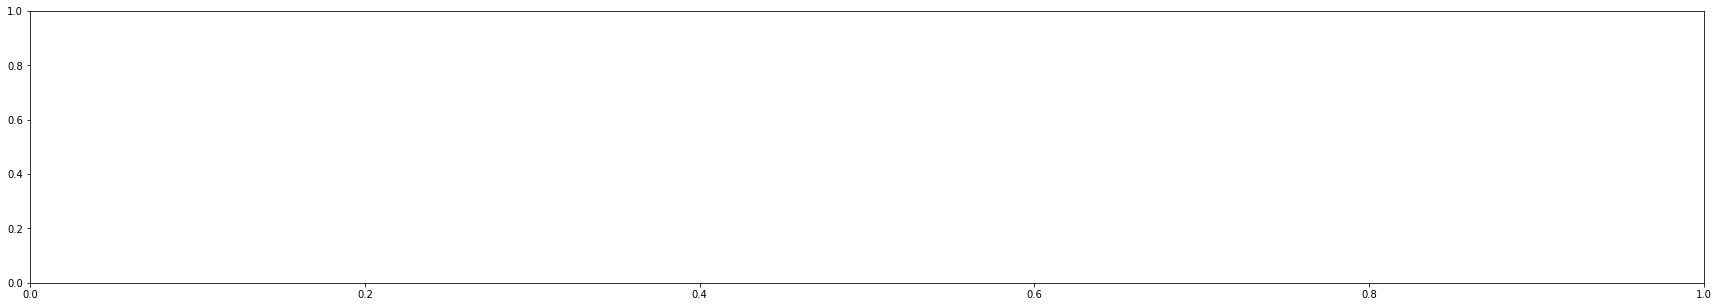

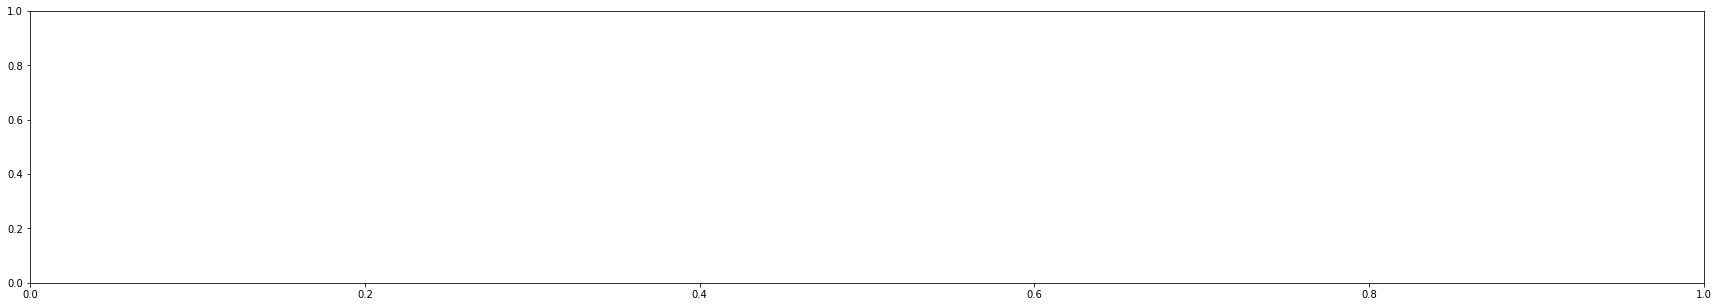

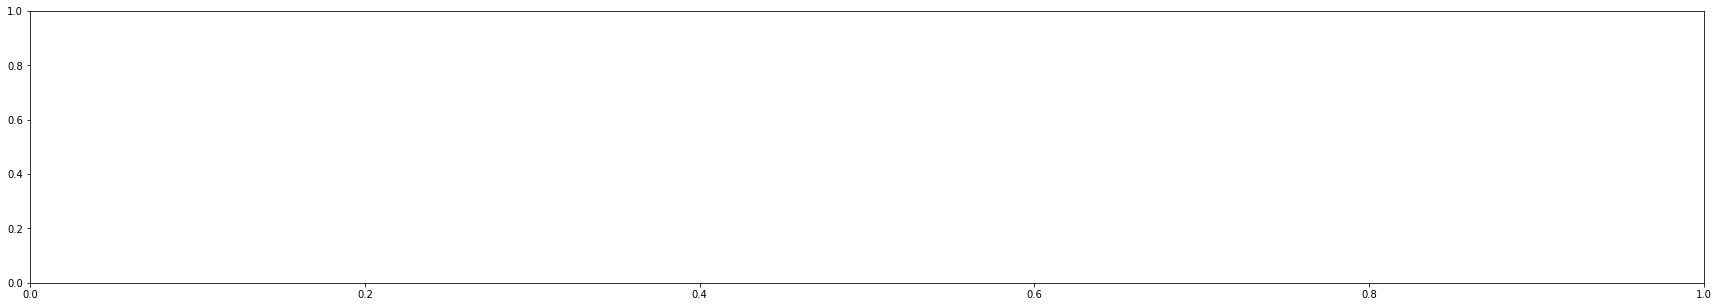

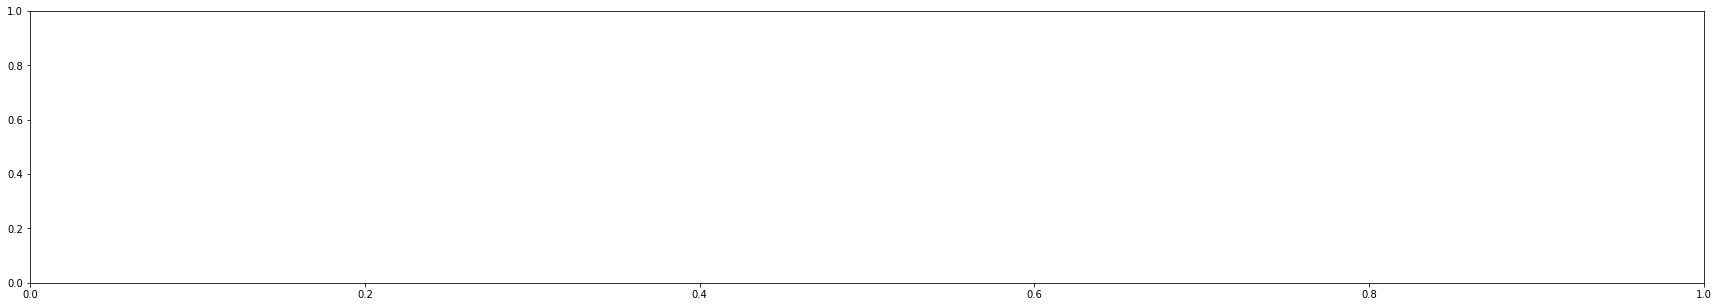

In [68]:
for c in allchr["chrID"].unique():
    plot_chr(c,d)
    plt.clf()
    plt.cla()